In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Load and Inspect data

In [13]:
df = pd.read_csv('../data/Pizza_data_analysis.csv')
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   restaurant_name  60 non-null     str    
 1   pizza_type       60 non-null     str    
 2   price_eur        60 non-null     float64
 3   size_cm          60 non-null     int64  
 4   district         60 non-null     str    
 5   central          60 non-null     int64  
 6   rating           60 non-null     float64
 7   review_count     60 non-null     int64  
 8   italian          60 non-null     int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 4.3 KB


,price_eur,size_cm,central,rating,review_count,italian
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,11.069500,31.050000,0.550000,4.385000,1408.650000,0.750000
std,2.190193,1.789091,0.501692,0.598536,1809.875741,0.436667
min,6.500000,26.000000,0.000000,2.400000,6.000000,0.000000
25%,9.375000,30.000000,0.000000,4.300000,125.000000,0.750000
50%,11.000000,32.000000,1.000000,4.550000,415.000000,1.000000
75%,12.922500,32.000000,1.000000,4.625000,2225.000000,1.000000
max,14.900000,33.000000,1.000000,5.000000,6400.000000,1.000000


In [10]:
df.isnull().sum()

restaurant_name    0
pizza_type         0
price_eur          0
size_cm            0
district           0
central            0
rating             0
review_count       0
italian            0
dtype: int64

In [16]:
#Creating price per cm² as pizza sizes are different

df['area_cm2'] = np.pi * (df['size_cm']/2)**2
df['price_per_cm2'] = df['price_eur']/df['area_cm2']
df.head()

,restaurant_name,pizza_type,price_eur,size_cm,district,central,rating,review_count,italian,area_cm2,price_per_cm2
0,Pizza Berlino,Margherita,10.5,32,Mitte,1,4.4,550,1,804.247719,0.013056
1,Pizza Berlino,Salami,13.9,32,Mitte,1,4.4,550,1,804.247719,0.017283
2,Pizza Berlino,Funghi,13.9,32,Mitte,1,4.4,550,1,804.247719,0.017283
3,Gino's Pizza & Pasta,Margherita,7.8,32,Kreuzberg,1,4.3,21,1,804.247719,0.009699
4,Gino's Pizza & Pasta,Salami,9.6,32,Kreuzberg,1,4.3,21,1,804.247719,0.011937


In [17]:
df.groupby('central')['price_per_cm2'].mean()

central
0    0.013506
1    0.015570
Name: price_per_cm2, dtype: float64

In [18]:
df.groupby('italian')['price_per_cm2'].mean()

italian
0    0.012849
1    0.015239
Name: price_per_cm2, dtype: float64

In [19]:
df[['price_per_cm2', 'rating']].corr()

,price_per_cm2,rating
price_per_cm2,1.000000,0.178679
rating,0.178679,1.000000


In [20]:
df.groupby('pizza_type')['price_per_cm2'].mean()

pizza_type
Funghi        0.015234
Margherita    0.013356
Salami        0.015333
Name: price_per_cm2, dtype: float64

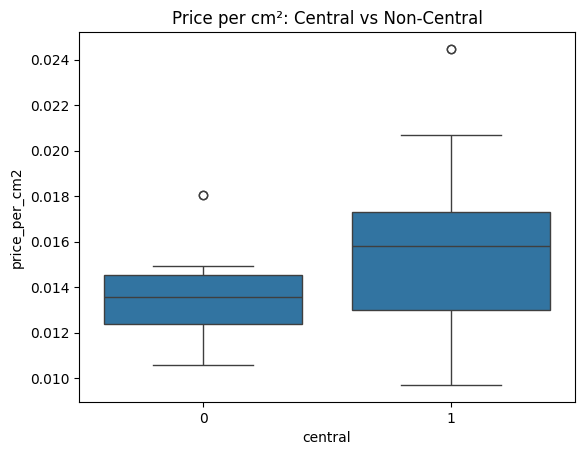

In [28]:
sns.boxplot(x="central", y="price_per_cm2", data=df)
plt.title("Price per cm²: Central vs Non-Central")
plt.show()

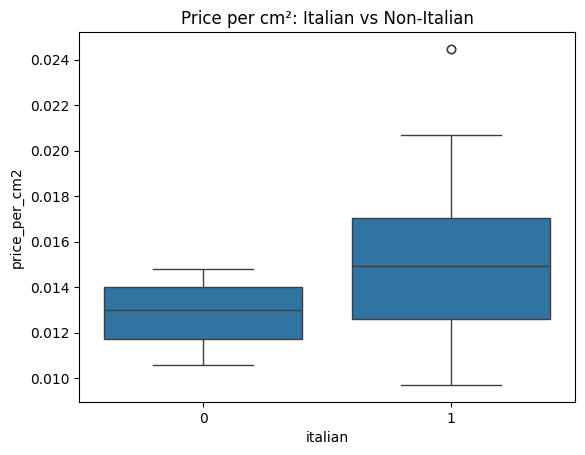

In [24]:
sns.boxplot(x="italian", y="price_per_cm2", data=df)
plt.title("Price per cm²: Italian vs Non-Italian")
plt.show()

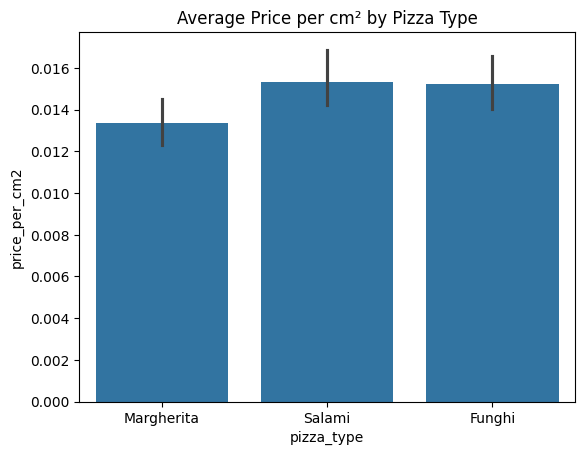

In [25]:
sns.barplot(x="pizza_type", y="price_per_cm2", data=df)
plt.title("Average Price per cm² by Pizza Type")
plt.show()